In [39]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
!pip install xgboost

  Using cached xgboost-3.3.0-py3-none-win_amd64.whl.metadata (2.0 kB)
Using cached xgboost-3.3.0-py3-none-win_amd64.whl (69.5 MB)



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
!pip install optuna

  Using cached optuna-4.9.0-py3-none-any.whl.metadata (15 kB)
  Using cached alembic-1.18.5-py3-none-any.whl.metadata (7.2 kB)
  Using cached colorlog-6.10.1-py3-none-any.whl.metadata (11 kB)
     ---------------------------------------- 0.0/57.4 kB ? eta -:--:--
     -------------------- ----------------- 30.7/57.4 kB 660.6 kB/s eta 0:00:01
     --------------------------------- ---- 51.2/57.4 kB 660.6 kB/s eta 0:00:01
     -------------------------------------- 57.4/57.4 kB 604.1 kB/s eta 0:00:00
  Using cached pyyaml-6.0.3-cp312-cp312-win_amd64.whl.metadata (2.4 kB)
  Using cached mako-1.3.12-py3-none-any.whl.metadata (2.9 kB)
Using cached optuna-4.9.0-py3-none-any.whl (425 kB)
Using cached alembic-1.18.5-py3-none-any.whl (264 kB)
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   - -------------------------------------- 0.1/2.1 MB 5.5 MB/s eta 0:00:01
   --- ------------------------------------ 0.2/2.1 MB 2.5 MB/s eta 0:00:01
   ------ -------------------------


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [3]:
data = pd.read_csv(r"D:\Bank-dashbourd\data\Churn_Modelling.csv")

In [30]:
data.shape

(10000, 14)

In [31]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [34]:
data.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [35]:
data.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [36]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


In [37]:
data.nunique()

RowNumber          10000
CustomerId         10000
Surname             2932
CreditScore          460
Geography              3
Gender                 2
Age                   70
Tenure                11
Balance             6382
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     9999
Exited                 2
dtype: int64

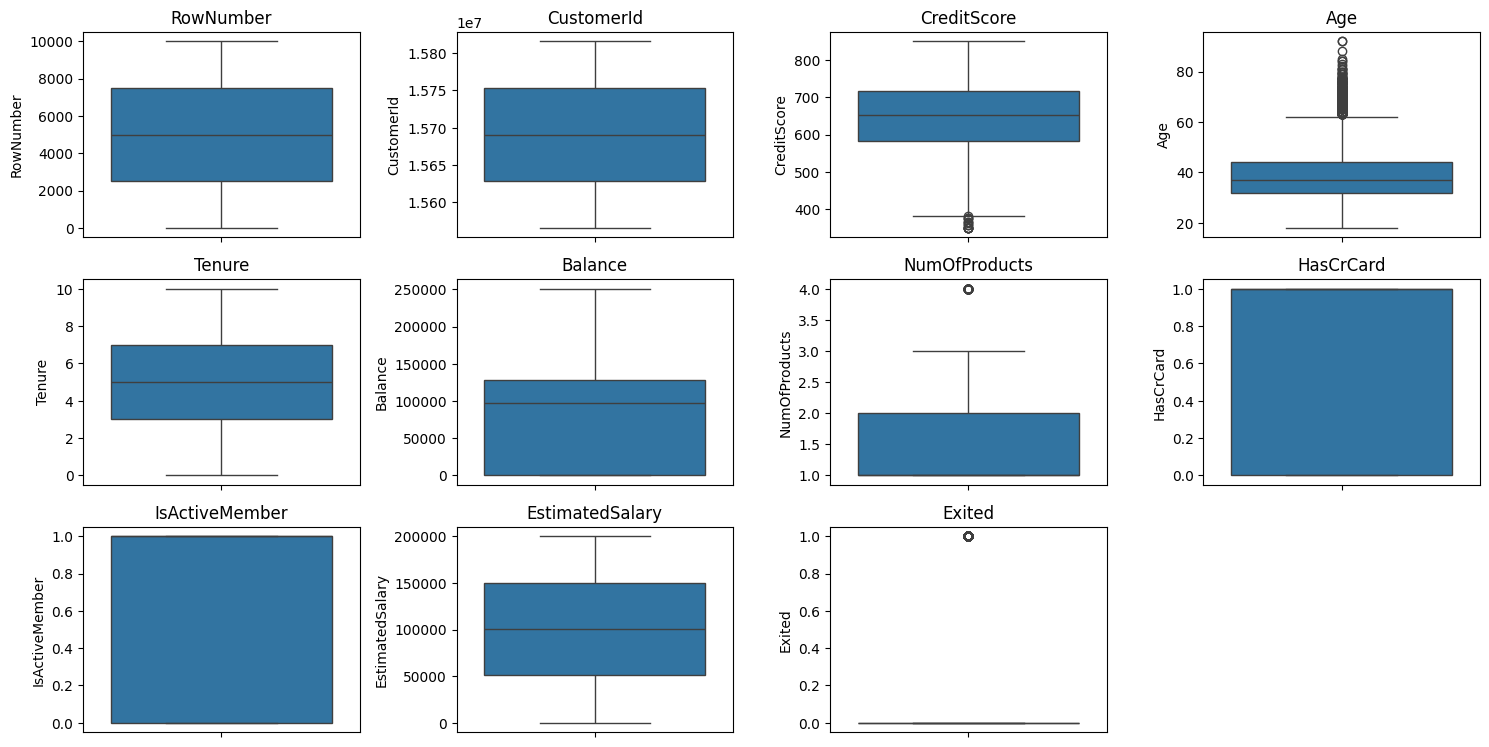

In [45]:
# for outlyirs
numeric_cols = data.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(15,10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4,4,i)
    sns.boxplot(y=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
#EDA
data["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

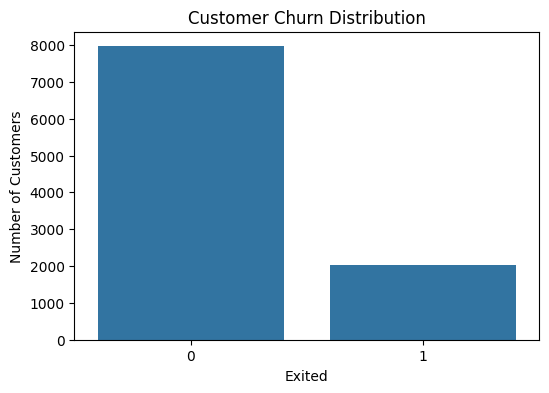

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x="Exited", data=data)

plt.title("Customer Churn Distribution")
plt.xlabel("Exited")
plt.ylabel("Number of Customers")

plt.show()

In [51]:
#customers left from each contury
churn_geo = data.groupby('Geography')['Exited'].mean().sort_values(ascending=False)

churn_geo

Geography
Germany    0.324432
Spain      0.166734
France     0.161548
Name: Exited, dtype: float64

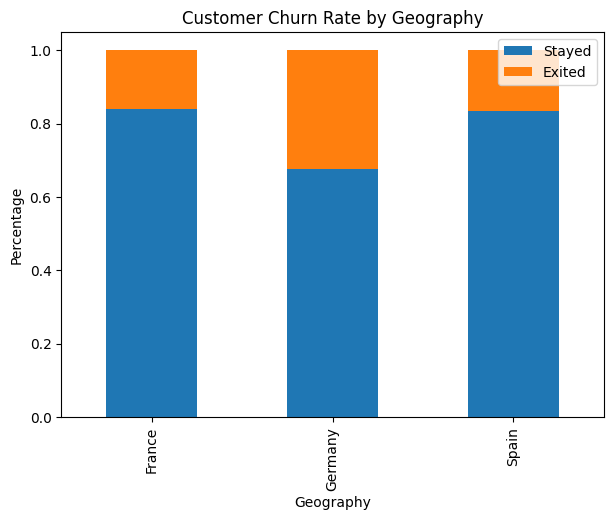

In [ ]:
geo = pd.crosstab(
    data["Geography"],
    data["Exited"],
    normalize="index"
)

geo.plot(
    kind="bar",
    stacked=True,
    figsize=(7,5)
)

plt.title("Customer Churn Rate by Geography")
plt.xlabel("Geography")
plt.ylabel("Percentage")

plt.legend(["Stayed","Exited"])

plt.show()

In [ ]:
churn_gender = data.groupby('Gender')['Exited'].mean().sort_values(ascending=False)

churn_gender

Gender
Female    0.250715
Male      0.164559
Name: Exited, dtype: float64

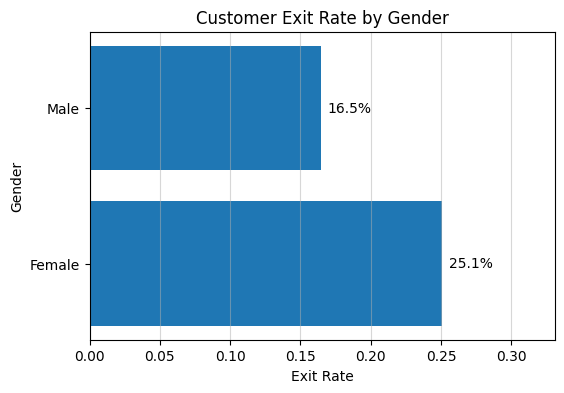

In [125]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

bars = plt.barh(
    churn_gender.index,
    churn_gender.values
)

for bar in bars:
    plt.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.1%}",
        va="center"
    )

plt.xlabel("Exit Rate")
plt.ylabel("Gender")
plt.title("Customer Exit Rate by Gender")

plt.xlim(0, max(churn_gender.values) + 0.08)

plt.grid(axis="x", alpha=0.5)

plt.show()

In [56]:
churn_active = data.groupby('IsActiveMember')['Exited'].mean()

churn_active

IsActiveMember
0    0.268509
1    0.142691
Name: Exited, dtype: float64

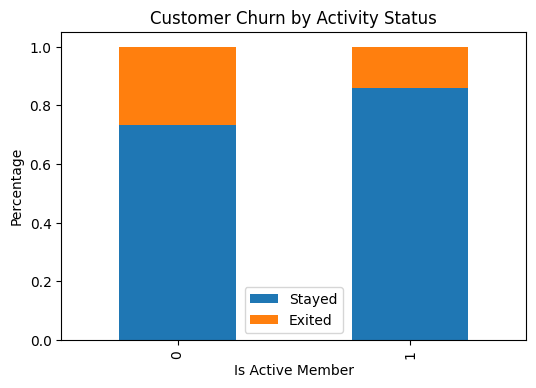

In [127]:
active = pd.crosstab(
    data["IsActiveMember"],
    data["Exited"],
    normalize="index"
)

active.plot(
    kind="bar",
    stacked=True,
    figsize=(6,4)
)

plt.title("Customer Churn by Activity Status")
plt.xlabel("Is Active Member")
plt.ylabel("Percentage")

plt.legend(["Stayed","Exited"])

plt.show()

In [61]:
churn_card = data.groupby('HasCrCard')['Exited'].mean()

churn_card

HasCrCard
0    0.208149
1    0.201843
Name: Exited, dtype: float64

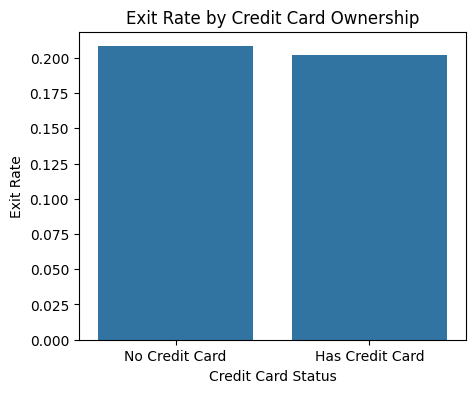

In [62]:
plt.figure(figsize=(5,4))

sns.barplot(
    x=churn_card.index,
    y=churn_card.values
)

plt.xticks(
    [0,1],
    ['No Credit Card','Has Credit Card']
)

plt.ylabel("Exit Rate")
plt.xlabel("Credit Card Status")
plt.title("Exit Rate by Credit Card Ownership")

plt.show()

In [60]:
data.groupby('Exited')['Age'].mean()

Exited
0    37.408389
1    44.837997
Name: Age, dtype: float64

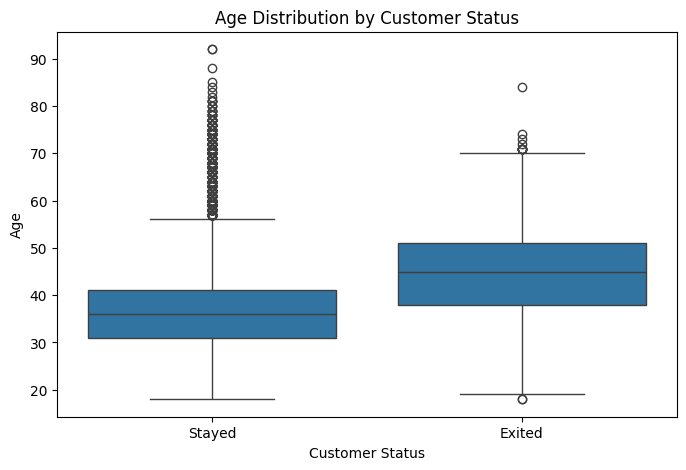

In [6]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Exited',
    y='Age',
    data=data
)

plt.xticks(
    [0,1],
    ['Stayed','Exited']
)

plt.xlabel("Customer Status")
plt.ylabel("Age")
plt.title("Age Distribution by Customer Status")

plt.show()

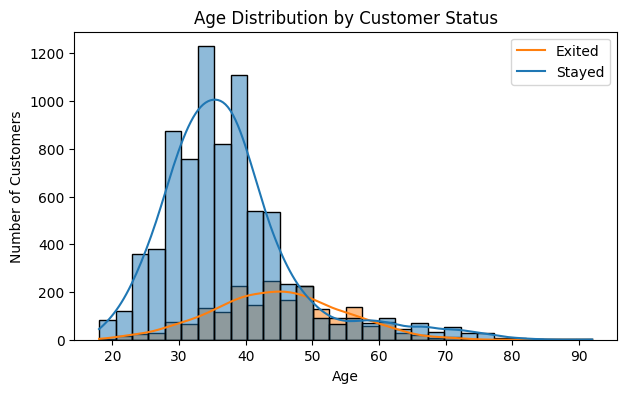

In [63]:
plt.figure(figsize=(7,4))

sns.histplot(
    data=data,
    x='Age',
    hue='Exited',
    bins=30,
    kde=True
)

plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Age Distribution by Customer Status")

plt.legend(
    labels=['Exited','Stayed']
)

plt.show()

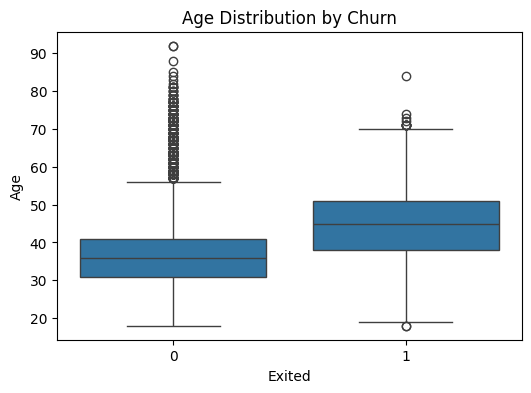

In [129]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="Exited",
    y="Age",
    data=data
)

plt.title("Age Distribution by Churn")

plt.show()

In [65]:
credit_mean = data.groupby('Exited')['CreditScore'].mean()

credit_mean

Exited
0    651.853196
1    645.351497
Name: CreditScore, dtype: float64

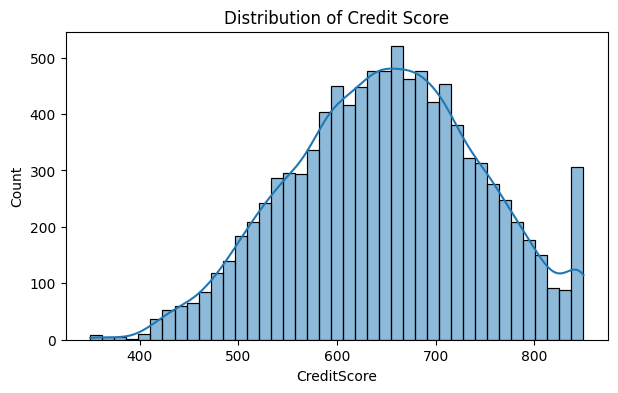

In [128]:
plt.figure(figsize=(7,4))

sns.histplot(
    data=data,
    x="CreditScore",
    kde=True
)

plt.title("Distribution of Credit Score")

plt.show()

In [67]:
balance_mean = data.groupby('Exited')['Balance'].mean()

balance_mean

Exited
0    72745.296779
1    91108.539337
Name: Balance, dtype: float64

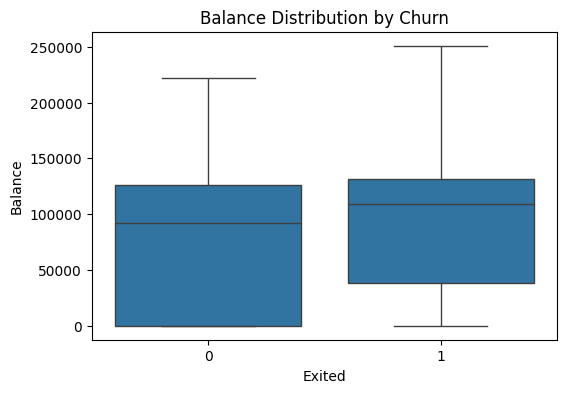

In [130]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="Exited",
    y="Balance",
    data=data
)

plt.title("Balance Distribution by Churn")

plt.show()

In [69]:
products_churn = data.groupby('NumOfProducts')['Exited'].mean()

products_churn

NumOfProducts
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: Exited, dtype: float64

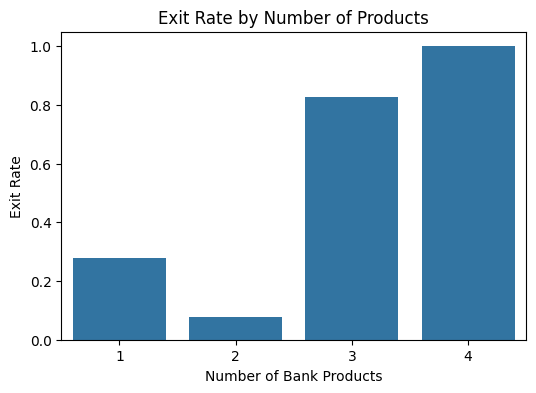

In [70]:
plt.figure(figsize=(6,4))

sns.barplot(
    x=products_churn.index,
    y=products_churn.values
)

plt.xlabel("Number of Bank Products")
plt.ylabel("Exit Rate")
plt.title("Exit Rate by Number of Products")

plt.show()

In [72]:
tenure_mean = data.groupby('Exited')['Tenure'].mean()

tenure_mean

Exited
0    5.033279
1    4.932744
Name: Tenure, dtype: float64

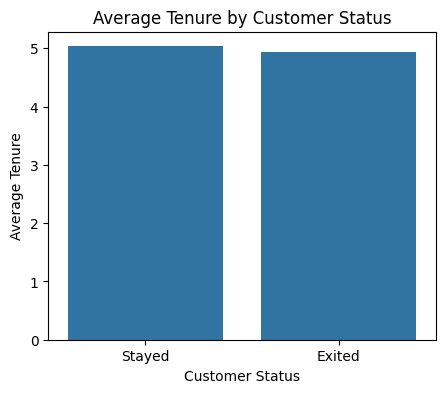

In [73]:
plt.figure(figsize=(5,4))

sns.barplot(
    x=tenure_mean.index,
    y=tenure_mean.values
)

plt.xticks(
    [0,1],
    ['Stayed','Exited']
)

plt.xlabel("Customer Status")
plt.ylabel("Average Tenure")
plt.title("Average Tenure by Customer Status")

plt.show()

In [74]:
salary_mean = data.groupby('Exited')['EstimatedSalary'].mean()

salary_mean

Exited
0     99738.391772
1    101465.677531
Name: EstimatedSalary, dtype: float64

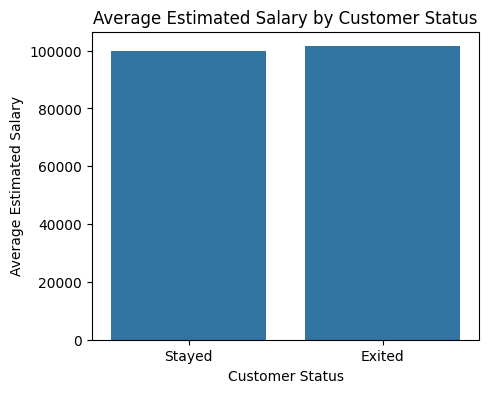

In [75]:
plt.figure(figsize=(5,4))

sns.barplot(
    x=salary_mean.index,
    y=salary_mean.values
)

plt.xticks(
    [0,1],
    ['Stayed','Exited']
)

plt.xlabel("Customer Status")
plt.ylabel("Average Estimated Salary")
plt.title("Average Estimated Salary by Customer Status")

plt.show()

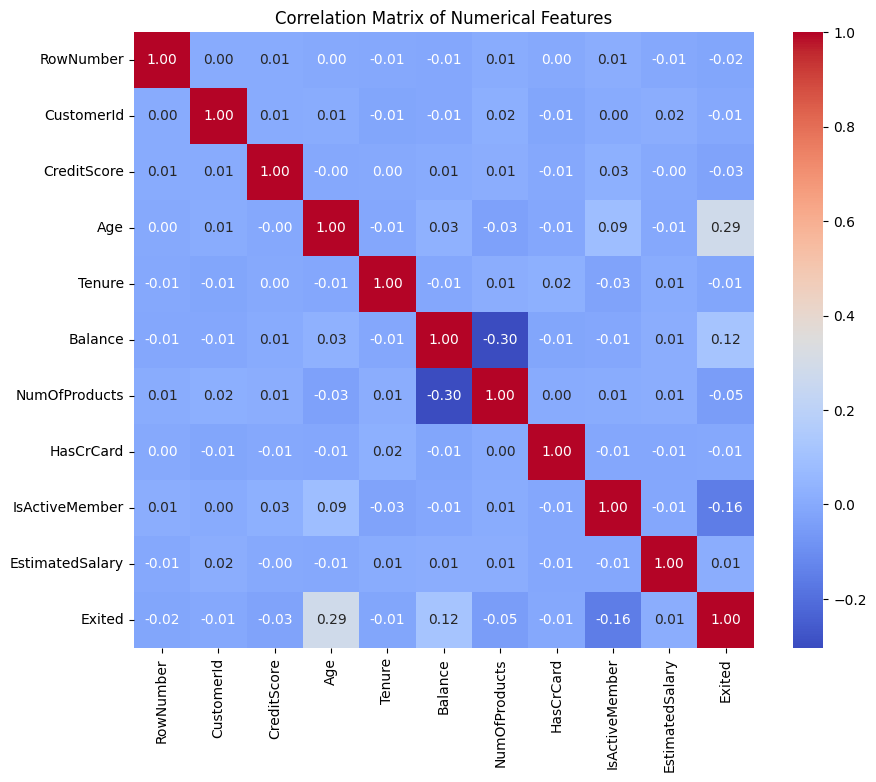

In [76]:
#correlation 
plt.figure(figsize=(10,8))

correlation_matrix = data.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

In [77]:
correlation_with_target = correlation_matrix['Exited'].sort_values(ascending=False)

correlation_with_target

Exited             1.000000
Age                0.285323
Balance            0.118533
EstimatedSalary    0.012097
CustomerId        -0.006248
HasCrCard         -0.007138
Tenure            -0.014001
RowNumber         -0.016571
CreditScore       -0.027094
NumOfProducts     -0.047820
IsActiveMember    -0.156128
Name: Exited, dtype: float64

In [4]:
#data preprocessing 
df_model = data.copy()

In [5]:
#customer with 1 accont and 1000 balance differ 1000 balcne for 3 accounts
df_model['BalancePerProduct'] = (
    df_model['Balance'] / df_model['NumOfProducts']
)

In [6]:
df_model[['Balance', 'NumOfProducts', 'BalancePerProduct']].head()

,Balance,NumOfProducts,BalancePerProduct
0,0.00,1,0.000000
1,83807.86,1,83807.860000
2,159660.80,3,53220.266667
3,0.00,2,0.000000
4,125510.82,1,125510.820000


In [7]:
#claen usless columns
df_model = df_model.drop(
    ['RowNumber', 'CustomerId', 'Surname'],
    axis=1
)

In [8]:
df_model.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalancePerProduct
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,83807.860000
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,53220.266667
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,125510.820000


In [83]:
df_model.shape

(10000, 12)

In [9]:
X = df_model.drop('Exited', axis=1)
y = df_model['Exited']

In [85]:
X.shape, y.shape

((10000, 11), (10000,))

In [10]:
#data split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y # cansethe target value is imbalnaced so to ensuer correct split
)

In [87]:
X_train.dtypes

CreditScore            int64
Geography             object
Gender                object
Age                    int64
Tenure                 int64
Balance              float64
NumOfProducts          int64
HasCrCard              int64
IsActiveMember         int64
EstimatedSalary      float64
BalancePerProduct    float64
dtype: object

In [11]:
#encoding and scaling
categorical_features = ['Geography', 'Gender']

numerical_features = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'NumOfProducts',
    'HasCrCard',
    'IsActiveMember',
    'EstimatedSalary',
    'BalancePerProduct'
]

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)# to avoid dummy variable trap
    ]
)

In [47]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [49]:
feature_names = preprocessor.get_feature_names_out()

print(feature_names)

['num__CreditScore' 'num__Age' 'num__Tenure' 'num__Balance'
 'num__NumOfProducts' 'num__HasCrCard' 'num__IsActiveMember'
 'num__EstimatedSalary' 'num__BalancePerProduct' 'cat__Geography_Germany'
 'cat__Geography_Spain' 'cat__Gender_Male']


In [44]:
X_train_processed.shape, X_test_processed.shape

((8000, 12), (2000, 12))

In [14]:
#MODELS 
#Logestic regression 
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model.fit(
    X_train_processed,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [15]:
y_pred_log = log_model.predict(X_test_processed)

In [16]:
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred_log))

print(classification_report(y_test, y_pred_log))

print("ROC-AUC:", roc_auc_score(y_test, log_model.predict_proba(X_test_processed)[:,1]))

Accuracy: 0.81
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.60      0.19      0.29       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000

ROC-AUC: 0.7745603847298763


In [17]:
#Random forest Classifier 
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(
    X_train_processed,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [18]:
y_pred_rf = rf_model.predict(X_test_processed)

In [19]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        rf_model.predict_proba(X_test_processed)[:,1]
    )
)

Accuracy: 0.866
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.78      0.48      0.59       407

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.76      2000
weighted avg       0.86      0.87      0.85      2000

ROC-AUC: 0.8528651918482427


In [23]:
#XGBoots model
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(
    X_train_processed,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [24]:
y_pred_xgb = xgb_model.predict(X_test_processed)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

print(classification_report(y_test, y_pred_xgb))

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        xgb_model.predict_proba(X_test_processed)[:,1]
    )
)

Accuracy: 0.846
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      1593
           1       0.67      0.48      0.56       407

    accuracy                           0.85      2000
   macro avg       0.77      0.71      0.73      2000
weighted avg       0.83      0.85      0.84      2000

ROC-AUC: 0.8343659530100207


In [25]:
#Hyperprameter tuning
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score


def objective(trial):

    model = RandomForestClassifier(
        n_estimators=trial.suggest_int(
            'n_estimators',
            100,
            500
        ),

        max_depth=trial.suggest_int(
            'max_depth',
            3,
            20
        ),

        min_samples_split=trial.suggest_int(
            'min_samples_split',
            2,
            10
        ),

        min_samples_leaf=trial.suggest_int(
            'min_samples_leaf',
            1,
            5
        ),

        class_weight='balanced',

        random_state=42
    )


    model.fit(
        X_train_processed,
        y_train
    )


    y_pred = model.predict(
        X_test_processed
    )


    return f1_score(
        y_test,
        y_pred
    )

d:\Bank-dashbourd\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [26]:
study = optuna.create_study(
    direction='maximize'
)

study.optimize(
    objective,
    n_trials=50
)

[I 2026-07-14 12:26:53,270] A new study created in memory with name: no-name-0549b603-eb9d-43a0-b275-c1098bd6ab57
[I 2026-07-14 12:26:55,962] Trial 0 finished with value: 0.6332970620239391 and parameters: {'n_estimators': 358, 'max_depth': 11, 'min_samples_split': 6, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.6332970620239391.
[I 2026-07-14 12:26:59,306] Trial 1 finished with value: 0.6261980830670927 and parameters: {'n_estimators': 468, 'max_depth': 12, 'min_samples_split': 3, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.6332970620239391.
[I 2026-07-14 12:27:02,362] Trial 2 finished with value: 0.617258883248731 and parameters: {'n_estimators': 498, 'max_depth': 8, 'min_samples_split': 3, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.6332970620239391.
[I 2026-07-14 12:27:04,113] Trial 3 finished with value: 0.594541910331384 and parameters: {'n_estimators': 403, 'max_depth': 4, 'min_samples_split': 5, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.

In [27]:
study.best_params # to use in the new model 

{'n_estimators': 110,
 'max_depth': 20,
 'min_samples_split': 10,
 'min_samples_leaf': 5}

In [28]:
study.best_value

0.6348862405200434

In [29]:
#the model with new prameters
best_rf = RandomForestClassifier(
    n_estimators=110,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)


best_rf.fit(
    X_train_processed,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",110
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1

In [30]:
y_pred_best_rf = best_rf.predict(
    X_test_processed
)

In [31]:
print("Accuracy:", accuracy_score(y_test, y_pred_best_rf))

print(classification_report(y_test, y_pred_best_rf))

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        best_rf.predict_proba(X_test_processed)[:,1]
    )
)

Accuracy: 0.8315
              precision    recall  f1-score   support

           0       0.92      0.86      0.89      1593
           1       0.57      0.72      0.63       407

    accuracy                           0.83      2000
   macro avg       0.75      0.79      0.76      2000
weighted avg       0.85      0.83      0.84      2000

ROC-AUC: 0.8626746931831678


In [53]:
from sklearn.pipeline import Pipeline
import joblib

model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', best_rf)
])

joblib.dump(model_pipeline, "../models/bank_churn_model.pkl")

['../models/bank_churn_model.pkl']

In [32]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost',
        'Tuned Random Forest'
    ],
    
    'Accuracy': [
        0.810,
        0.866,
        0.846,
        0.854
    ],
    
    'Recall_Exited': [
        0.19,
        0.48,
        0.48,
        0.66
    ],
    
    'F1_Exited': [
        0.29,
        0.59,
        0.56,
        0.65
    ],
    
    'ROC-AUC': [
        0.775,
        0.853,
        0.834,
        0.864
    ]
})

comparison

,Model,Accuracy,Recall_Exited,F1_Exited,ROC-AUC
0,Logistic Regression,0.810,0.19,0.29,0.775
1,Random Forest,0.866,0.48,0.59,0.853
2,XGBoost,0.846,0.48,0.56,0.834
3,Tuned Random Forest,0.854,0.66,0.65,0.864


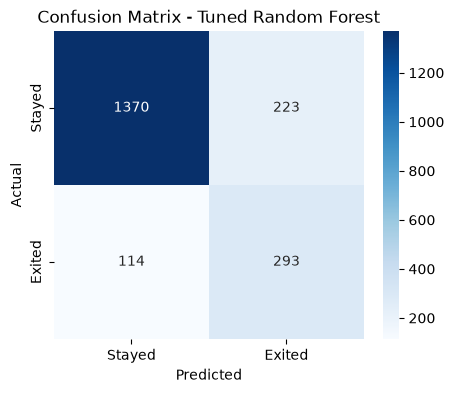

In [33]:
#confusion matrics
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(
    y_test,
    y_pred_best_rf
)


plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Stayed','Exited'],
    yticklabels=['Stayed','Exited']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned Random Forest")

plt.show()

In [34]:
#featuer importance
feature_names = preprocessor.get_feature_names_out()

feature_names

array(['num__CreditScore', 'num__Age', 'num__Tenure', 'num__Balance',
       'num__NumOfProducts', 'num__HasCrCard', 'num__IsActiveMember',
       'num__EstimatedSalary', 'num__BalancePerProduct',
       'cat__Geography_Germany', 'cat__Geography_Spain',
       'cat__Gender_Male'], dtype=object)

In [35]:
best_rf.feature_importances_

array([0.07765853, 0.29435474, 0.04636714, 0.09265098, 0.1720022 ,
       0.01084264, 0.04671677, 0.08104818, 0.09970476, 0.04617371,
       0.01095442, 0.02152593])

In [36]:
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
1,num__Age,0.294355
4,num__NumOfProducts,0.172002
8,num__BalancePerProduct,0.099705
3,num__Balance,0.092651
7,num__EstimatedSalary,0.081048
0,num__CreditScore,0.077659
6,num__IsActiveMember,0.046717
2,num__Tenure,0.046367
9,cat__Geography_Germany,0.046174
11,cat__Gender_Male,0.021526


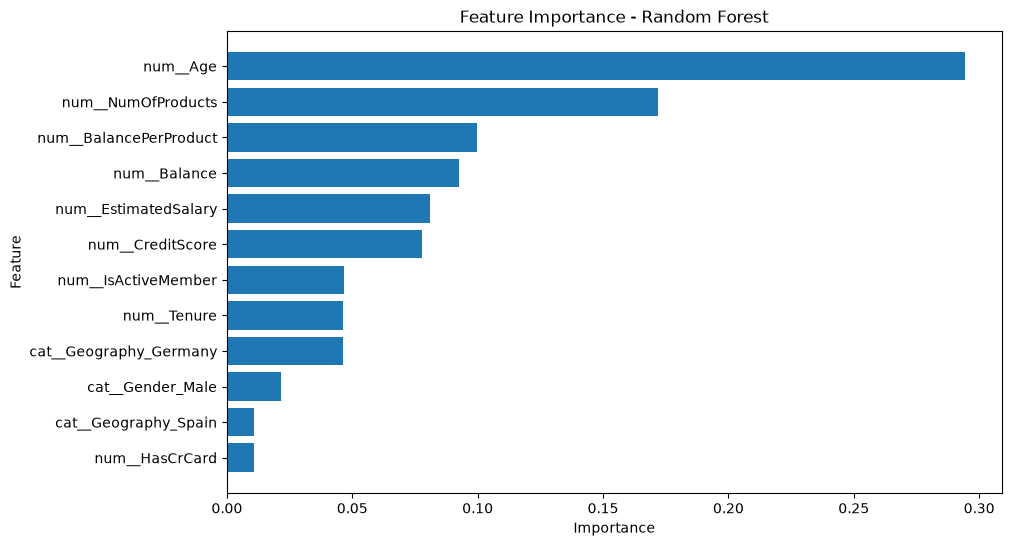

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Random Forest")

plt.gca().invert_yaxis()

plt.show()


In [2]:
import joblib

model = joblib.load("../models/bank_churn_model.pkl")

print(model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary',
                                                   'BalancePerProduct']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Geography', 'Gender'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=20,
                                        min_samples_leaf=5,
                                        min_samples_split=10, n_estimator